In [1]:
# Demo file for working with univariate data
# live entstanden in der Vorlesung AIN Stoachstik, 26.03.2026
#
# copyright: Barbara Staehle, HTWG Konstanz
# bstaehle@htwg-konstanz.de

# import library we use for plotting and calculating
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as stat

In [2]:
# read data from excelfile
# for excel-file, see Moodle!
umfrage = pd.read_excel('../../data/zehn_Fragen_ss26_clean.xlsx')
# Daten ausgeben
#print(umfrage)
data = umfrage['Q05_Stochastik-Vorwissen'] # ['Q01_Körpergröße'] # 
gib_data = umfrage[umfrage['Kurs'].str.contains('Mathematik', case=False, na=False)]['Q05_Stochastik-Vorwissen'] # 
ain_data = umfrage[umfrage['Kurs'].str.contains('Stochastik', case=False, na=False)]['Q05_Stochastik-Vorwissen'] # 


In [3]:
# Wiederholung: Mittelwerte, Median, Modalwerte für die verschiedenen Datenreihen
print(f"mean GIB: {np.mean(gib_data):.3f}")
print(f"mean AIN: {np.mean(ain_data)}")
print(f"mean AIN+GIB: {np.mean(data)}")

print(f"median GIB: {np.median(gib_data)}")
print(f"median AIN: {np.median(ain_data)}")
print(f"median AIN+GIB: {np.median(data)}")

print(f"Modalwert(e) GIB: {stat.multimode(gib_data)}")
print(f"Modalwert(e) AIN: {stat.multimode(ain_data)}") 
print(f"Modalwert(e) AIN+GIB: {stat.multimode(data)}") 


mean GIB: 3.286
mean AIN: 4.0
mean AIN+GIB: 3.6
median GIB: 3.5
median AIN: 4.0
median AIN+GIB: 4.0
Modalwert(e) GIB: [4, 2]
Modalwert(e) AIN: [4, 3, 6]
Modalwert(e) AIN+GIB: [4]


In [4]:
# Berechne [25, 75, 90]-Quantile
# np.percentile nimmt Werte von 0-100
# np.quantile nimmt Werte von 0-1
for p in [25, 75, 90]:
    print(f"{p}%-Quantil GIB: {np.percentile(gib_data,p):.3f}")
    print(f"{p}%-Quantil AIN: {np.percentile(ain_data,p):.3f}")
    print(f"{p}%-Quantil AIN+GIB: {np.percentile(data,p):.3f}")

25%-Quantil GIB: 2.000
25%-Quantil AIN: 2.500
25%-Quantil AIN+GIB: 2.000
75%-Quantil GIB: 4.750
75%-Quantil AIN: 6.000
75%-Quantil AIN+GIB: 5.000
90%-Quantil GIB: 5.700
90%-Quantil AIN: 7.000
90%-Quantil AIN+GIB: 6.600


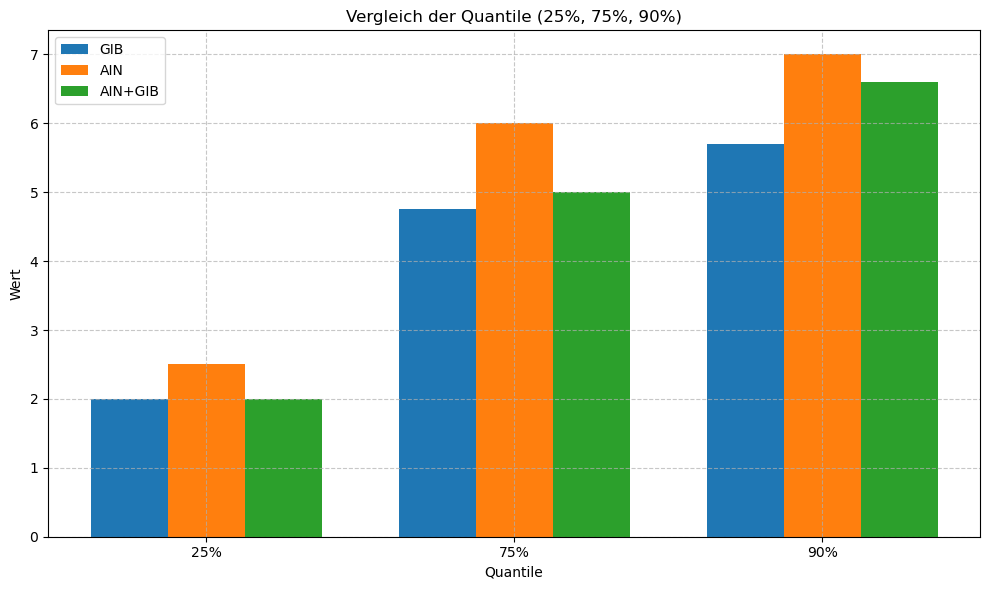

In [5]:
# stelle die berechneten Quantile graphisch dar
# Co author: LeChat

# Berechne die Quantile für jede Gruppe
quantiles = [25, 75, 90]
# Original-Code von LeChat
#gib_quantiles = [np.percentile(gib_data, p) for p in quantiles]

# schlauere, intuivere Formulierung ohne Schleifen
gib_quantiles = np.percentile(gib_data, quantiles)
ain_quantiles = np.percentile(ain_data, quantiles)
wissen_quantiles = np.percentile(data, quantiles)

# Position der Balken
x = np.arange(len(quantiles))  # Positionen für die Quantile (25, 75, p*100)
width = 0.25  # Breite der Balken

# Plot erstellen
plt.figure(figsize=(10, 6))

# Balken für GIB (blau)
plt.bar(x - width, gib_quantiles, width, label='GIB', color='C0')

# Balken für AIN (orange)
plt.bar(x, ain_quantiles, width, label='AIN', color='C1')

# Balken für AIN+GIB (grün)
plt.bar(x + width, wissen_quantiles, width, label='AIN+GIB', color='C2')

# Titel und Beschriftungen
plt.title('Vergleich der Quantile (25%, 75%, 90%)')
plt.xlabel('Quantile')
plt.ylabel('Wert')
plt.xticks(x, [f'{p}%' for p in quantiles])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot anzeigen
plt.tight_layout()
plt.show()

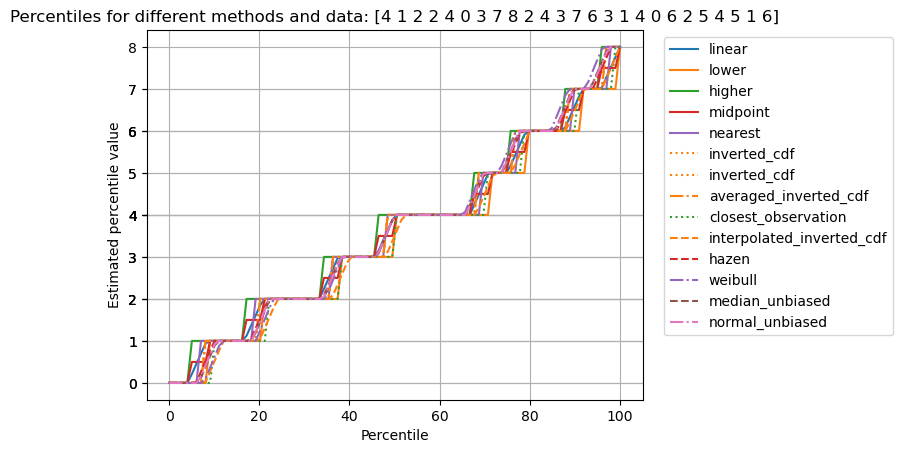

In [6]:
# Beispiel wie die unterscheidelichen Methoden zur Quantil-Berechung funktionieren
# Example adapted from https://numpy.org/doc/stable/reference/generated/numpy.percentile.html#numpy.percentile
# Original-Beispiel
#a = np.arange(4) # [0,1,2,3]

#Beispiel: Stochastik-Vorwissen
a = np.array(data)

# die anzusehenden Quantile
p = np.linspace(0, 100, 100) # 6001 (original in Doku)
ax = plt.gca()
lines = [
    ('linear', '-', 'C0'),
    ('lower','-', 'C1'),
    ('higher','-', 'C2'),
    ('midpoint','-', 'C3'),
    ('nearest','-', 'C4'),
    ('inverted_cdf', ':', 'C1'),
    ('inverted_cdf', ':', 'C1'),
    # Almost the same as `inverted_cdf`:
    ('averaged_inverted_cdf', '-.', 'C1'),
    ('closest_observation', ':', 'C2'),
    ('interpolated_inverted_cdf', '--', 'C1'),
    ('hazen', '--', 'C3'),
    ('weibull', '-.', 'C4'),
    ('median_unbiased', '--', 'C5'),
    ('normal_unbiased', '-.', 'C6'),
    ]
for method, style, color in lines:
    ax.plot(
        p, np.percentile(a, p, method=method),
        label=method, linestyle=style, color=color)
ax.set(
    title='Percentiles for different methods and data: ' + str(a),
    xlabel='Percentile',
    ylabel='Estimated percentile value',
    yticks=a)
ax.legend(bbox_to_anchor=(1.03, 1))
#plt.tight_layout()
plt.grid(True)
plt.show()

In [7]:
# Quantilberechnungsformel wie im Skript
import math 

def my_quantile(d, p):
    """
    Hilfsfunktion - Berechnet das p-Quantil der Daten d wie im Skript definiert
    Original in Matlab von Barbara Staehle, Übersetzung nach Python: LeChat
    """
    ds = sorted(d)  # Sortiere die Daten
    n = len(d)      # Länge der Daten
    np = n * p
    
    if (np).is_integer():  # Prüfe, ob n*p eine ganze Zahl ist
        # falls ja:
        try:
            q = (ds[int(np)-1] + ds[int(np)]) / 2  # Mittelwert der benachbarten Werte
        except: # koennte passieren, dass np = n ist
             q = (ds[int(np)-1] + ds[int(np)-1]) / 2
    else:
        #
        q = ds[math.ceil(np) - 1]  # Ceiling-Operation (Python-Index beginnt bei 0)

    return q

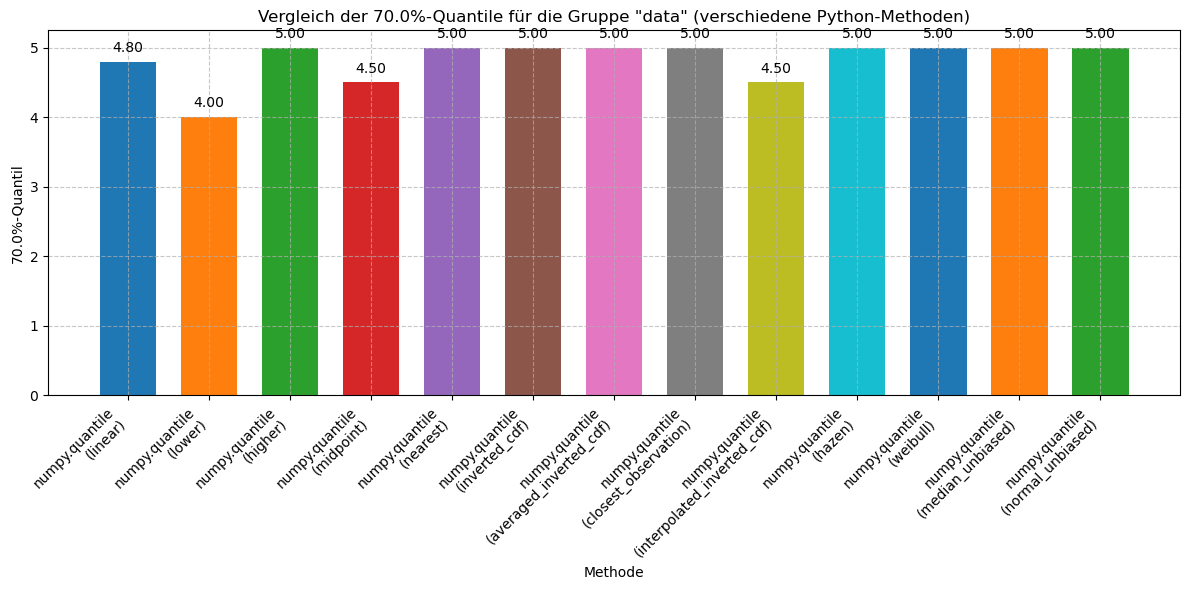

In [8]:
# Berechne das p*100%-Quantil mit allen Methoden für die Gruppe "data"
# Coauthor: LeChat

p = 0.7


methods = {
     'numpy.quantile\n(linear)':               np.quantile(data, p, method='linear'),
    'numpy.quantile\n(lower)':                np.quantile(data, p, method='lower'),
    'numpy.quantile\n(higher)':               np.quantile(data, p, method='higher'),
    'numpy.quantile\n(midpoint)':             np.quantile(data, p, method='midpoint'),
    'numpy.quantile\n(nearest)':              np.quantile(data, p, method='nearest'),
    'numpy.quantile\n(inverted_cdf)':         np.quantile(data, p, method='inverted_cdf'),
    'numpy.quantile\n(averaged_inverted_cdf)':np.quantile(data, p, method='averaged_inverted_cdf'),
    'numpy.quantile\n(closest_observation)':  np.quantile(data, p, method='closest_observation'),
    'numpy.quantile\n(interpolated_inverted_cdf)': np.quantile(data, p, method='interpolated_inverted_cdf'),
    'numpy.quantile\n(hazen)':                np.quantile(data, p, method='hazen'),
    'numpy.quantile\n(weibull)':              np.quantile(data, p, method='weibull'),
    'numpy.quantile\n(median_unbiased)':      np.quantile(data, p, method='median_unbiased'),
    'numpy.quantile\n(normal_unbiased)':      np.quantile(data, p, method='normal_unbiased'),
    #'my_quantile\n(selbstgeschrieben)':        my_quantile(data, p)
}

# Positionen für Quantile-Balken
x = np.arange(len(methods))  # Positionen für die Methoden
width = 0.7  # Breite der Balken

# Plot erstellen
plt.figure(figsize=(12, 6))

# Balken für die Quantile aller Methoden
bars = plt.bar(x, methods.values(), width=width,
               color=[f'C{i}' for i in range(len(methods))])

# Titel und Beschriftungen
plt.title(f'Vergleich der {p*100}%-Quantile für die Gruppe "data" (verschiedene Python-Methoden)')
plt.xlabel('Methode')
plt.ylabel(f'{p*100}%-Quantil')
plt.xticks(x, methods.keys(), rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)

# Werte auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02 * max(methods.values()),
             f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [9]:
# Beispielvektor aus dem Skript 
y = [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 7]
print(f'Mean: {np.mean(y)}')
print(f'Varianz (falsch, falls Stichprobe): {np.var(y):.3f}')
print(f'Standardabweichung (falsch, falls Stichprobe): {np.std(y):.3f}')
print(f'empirische Varianz: {np.var(y,ddof=1):.3f}')
print(f'empirische Standardabweichung: {np.std(y,ddof=1):.3f}')


Mean: 3.0
Varianz (falsch, falls Stichprobe): 2.545
Standardabweichung (falsch, falls Stichprobe): 1.595
empirische Varianz: 2.800
empirische Standardabweichung: 1.673


In [10]:
print(f'empirische Standardabweichung für AIN+GIB: {np.std(data,ddof=1):.3f}')
print(f'empirische Standardabweichung für AIN: {np.std(ain_data,ddof=1):.3f}')
print(f'empirische Standardabweichung für GIB: {np.std(gib_data,ddof=1):.3f}')

empirische Standardabweichung für AIN+GIB: 2.255
empirische Standardabweichung für AIN: 2.530
empirische Standardabweichung für GIB: 2.054


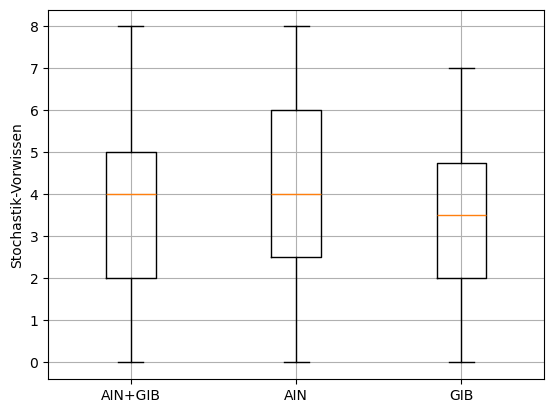

In [11]:
# Boxplot, zum Vergleich des Wissens der Studierenden
plt.boxplot([data,ain_data,gib_data])
plt.grid(True)
plt.xticks([1, 2,3], ['AIN+GIB','AIN','GIB'])
#plt.xlabel('Studiengang')
plt.ylabel('Stochastik-Vorwissen')
plt.show()


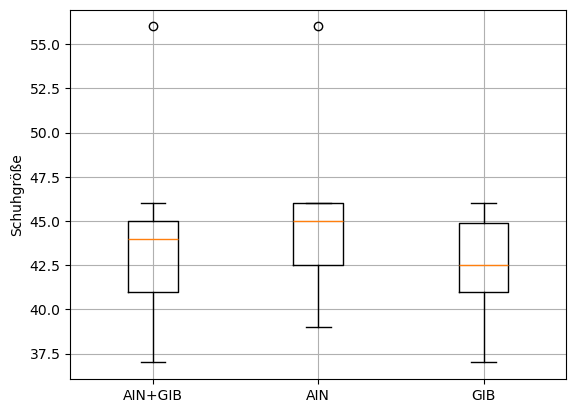

In [12]:
# Boxplot, zum Vergleich der Schuhgröße der Studierenden
data = umfrage['Q02_Schuhgröße']
gib_data = umfrage[umfrage['Kurs'].str.contains('Mathematik', case=False, na=False)]['Q02_Schuhgröße'] # 
ain_data = umfrage[umfrage['Kurs'].str.contains('Stochastik', case=False, na=False)]['Q02_Schuhgröße'] # 

plt.boxplot([data,ain_data,gib_data])
#plt.boxplot(data)
plt.grid(True)
plt.xticks([1, 2,3], ['AIN+GIB','AIN','GIB'])
plt.ylabel('Schuhgröße')
plt.show() 

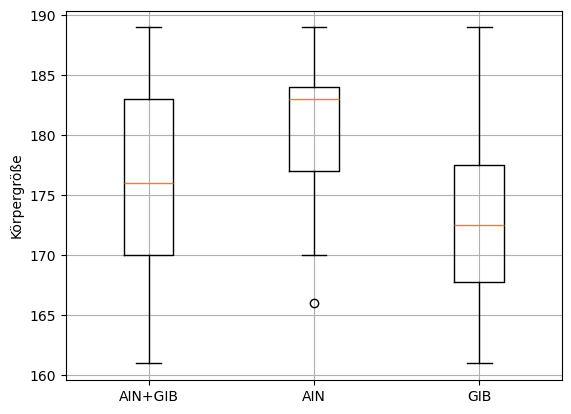

In [13]:
# Boxplot, zum Vergleich der Größe der Studierenden
data = umfrage['Q01_Körpergröße'] 
gib_data = umfrage[umfrage['Kurs'].str.contains('Mathematik', case=False, na=False)]['Q01_Körpergröße'] 
ain_data = umfrage[umfrage['Kurs'].str.contains('Stochastik', case=False, na=False)]['Q01_Körpergröße'] 

plt.boxplot([data,ain_data,gib_data])
plt.grid(True)
plt.xticks([1, 2,3], ['AIN+GIB','AIN','GIB'])
plt.ylabel('Körpergröße')
plt.show() 

In [14]:
print(f'empirische Standardabweichung für AIN+GIB: {np.std(data,ddof=1):.3f}')
print(f'empirische Standardabweichung für AIN: {np.std(ain_data,ddof=1):.3f}')
print(f'empirische Standardabweichung für GIB: {np.std(gib_data,ddof=1):.3f}')

empirische Standardabweichung für AIN+GIB: 8.880
empirische Standardabweichung für AIN: 7.115
empirische Standardabweichung für GIB: 9.059


In [15]:
print(f"mean GIB: {np.mean(gib_data):.3f}")
print(f"mean AIN: {np.mean(ain_data):.3f}")
print(f"mean AIN+GIB: {np.mean(data)}")


mean GIB: 173.071
mean AIN: 180.273
mean AIN+GIB: 176.24


In [24]:
# nur die quantitativen Merkmale (Zahlen) der Umfrage
numvals = umfrage.drop(columns=umfrage.columns[:4])
numvals = numvals.drop(columns=numvals.columns[3])
numvals = numvals.drop(columns=numvals.columns[6])

#print(numvals)

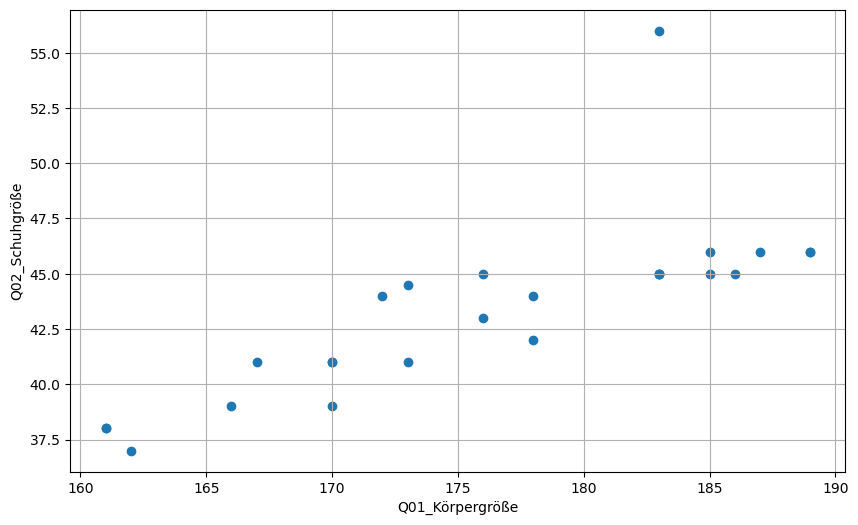

In [17]:
# Scatterplot Körpergröße vs. Schuhgröße
plt.figure(figsize=(10, 6))
plt.scatter(numvals['Q01_Körpergröße'], numvals['Q02_Schuhgröße'])
plt.grid(True)
plt.xlabel('Q01_Körpergröße')
plt.ylabel('Q02_Schuhgröße')
plt.show()

In [18]:
# Korrelationskoeffizient mit pandas
correlation = numvals[['Q01_Körpergröße', 'Q02_Schuhgröße']].corr()
print(correlation)

                 Q01_Körpergröße  Q02_Schuhgröße
Q01_Körpergröße         1.000000        0.774626
Q02_Schuhgröße          0.774626        1.000000


In [19]:
print('Korrelation', correlation.iloc[0,1])

Korrelation 0.7746264089385602


In [20]:
# Korrelationskoeffizient mit numpy
np.corrcoef(numvals[['Q01_Körpergröße', 'Q02_Schuhgröße']],rowvar=False)

array([[1.        , 0.77462641],
       [0.77462641, 1.        ]])

In [21]:
# Korrelationskoeffizienten für alle Daten
corrmatrix = numvals.corr()
print(corrmatrix)

                                Q01_Körpergröße  Q02_Schuhgröße  \
Q01_Körpergröße                        1.000000        0.774626   
Q02_Schuhgröße                         0.774626        1.000000   
Q03_Welches Semester                   0.150736        0.066585   
Q05_Stochastik-Vorwissen              -0.072006        0.007099   
Q06_Wie viele Jahre Mathematik        -0.151836        0.014946   
Q07_Geburtsjahr                        0.067591        0.001212   
Q09_Wie viel Wasser Training          -0.026613        0.092700   
Q10_Wie viel Wasser Antwort           -0.210248       -0.286552   

                                Q03_Welches Semester  \
Q01_Körpergröße                             0.150736   
Q02_Schuhgröße                              0.066585   
Q03_Welches Semester                        1.000000   
Q05_Stochastik-Vorwissen                    0.030086   
Q06_Wie viele Jahre Mathematik             -0.063586   
Q07_Geburtsjahr                            -0.190085   
Q09_

<Axes: >

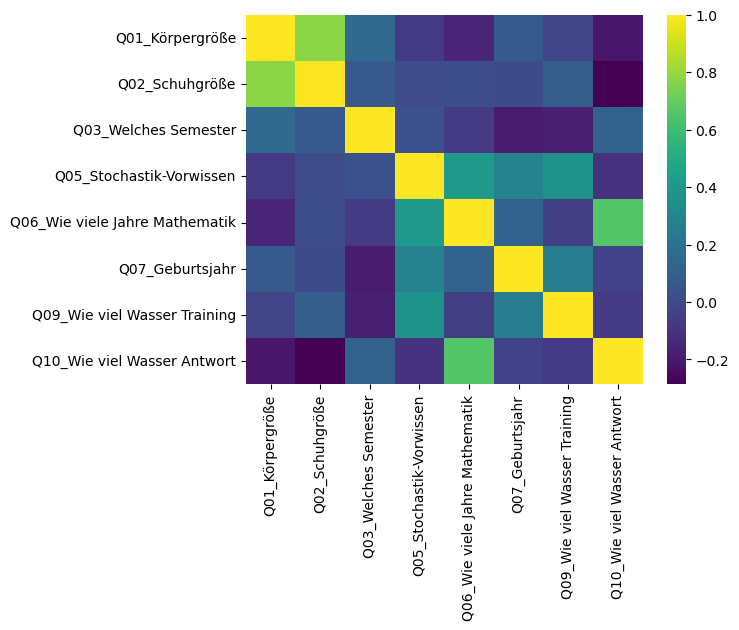

In [22]:
# als heatmap darstellen
import seaborn as sns
sns.heatmap(corrmatrix,cmap='viridis')

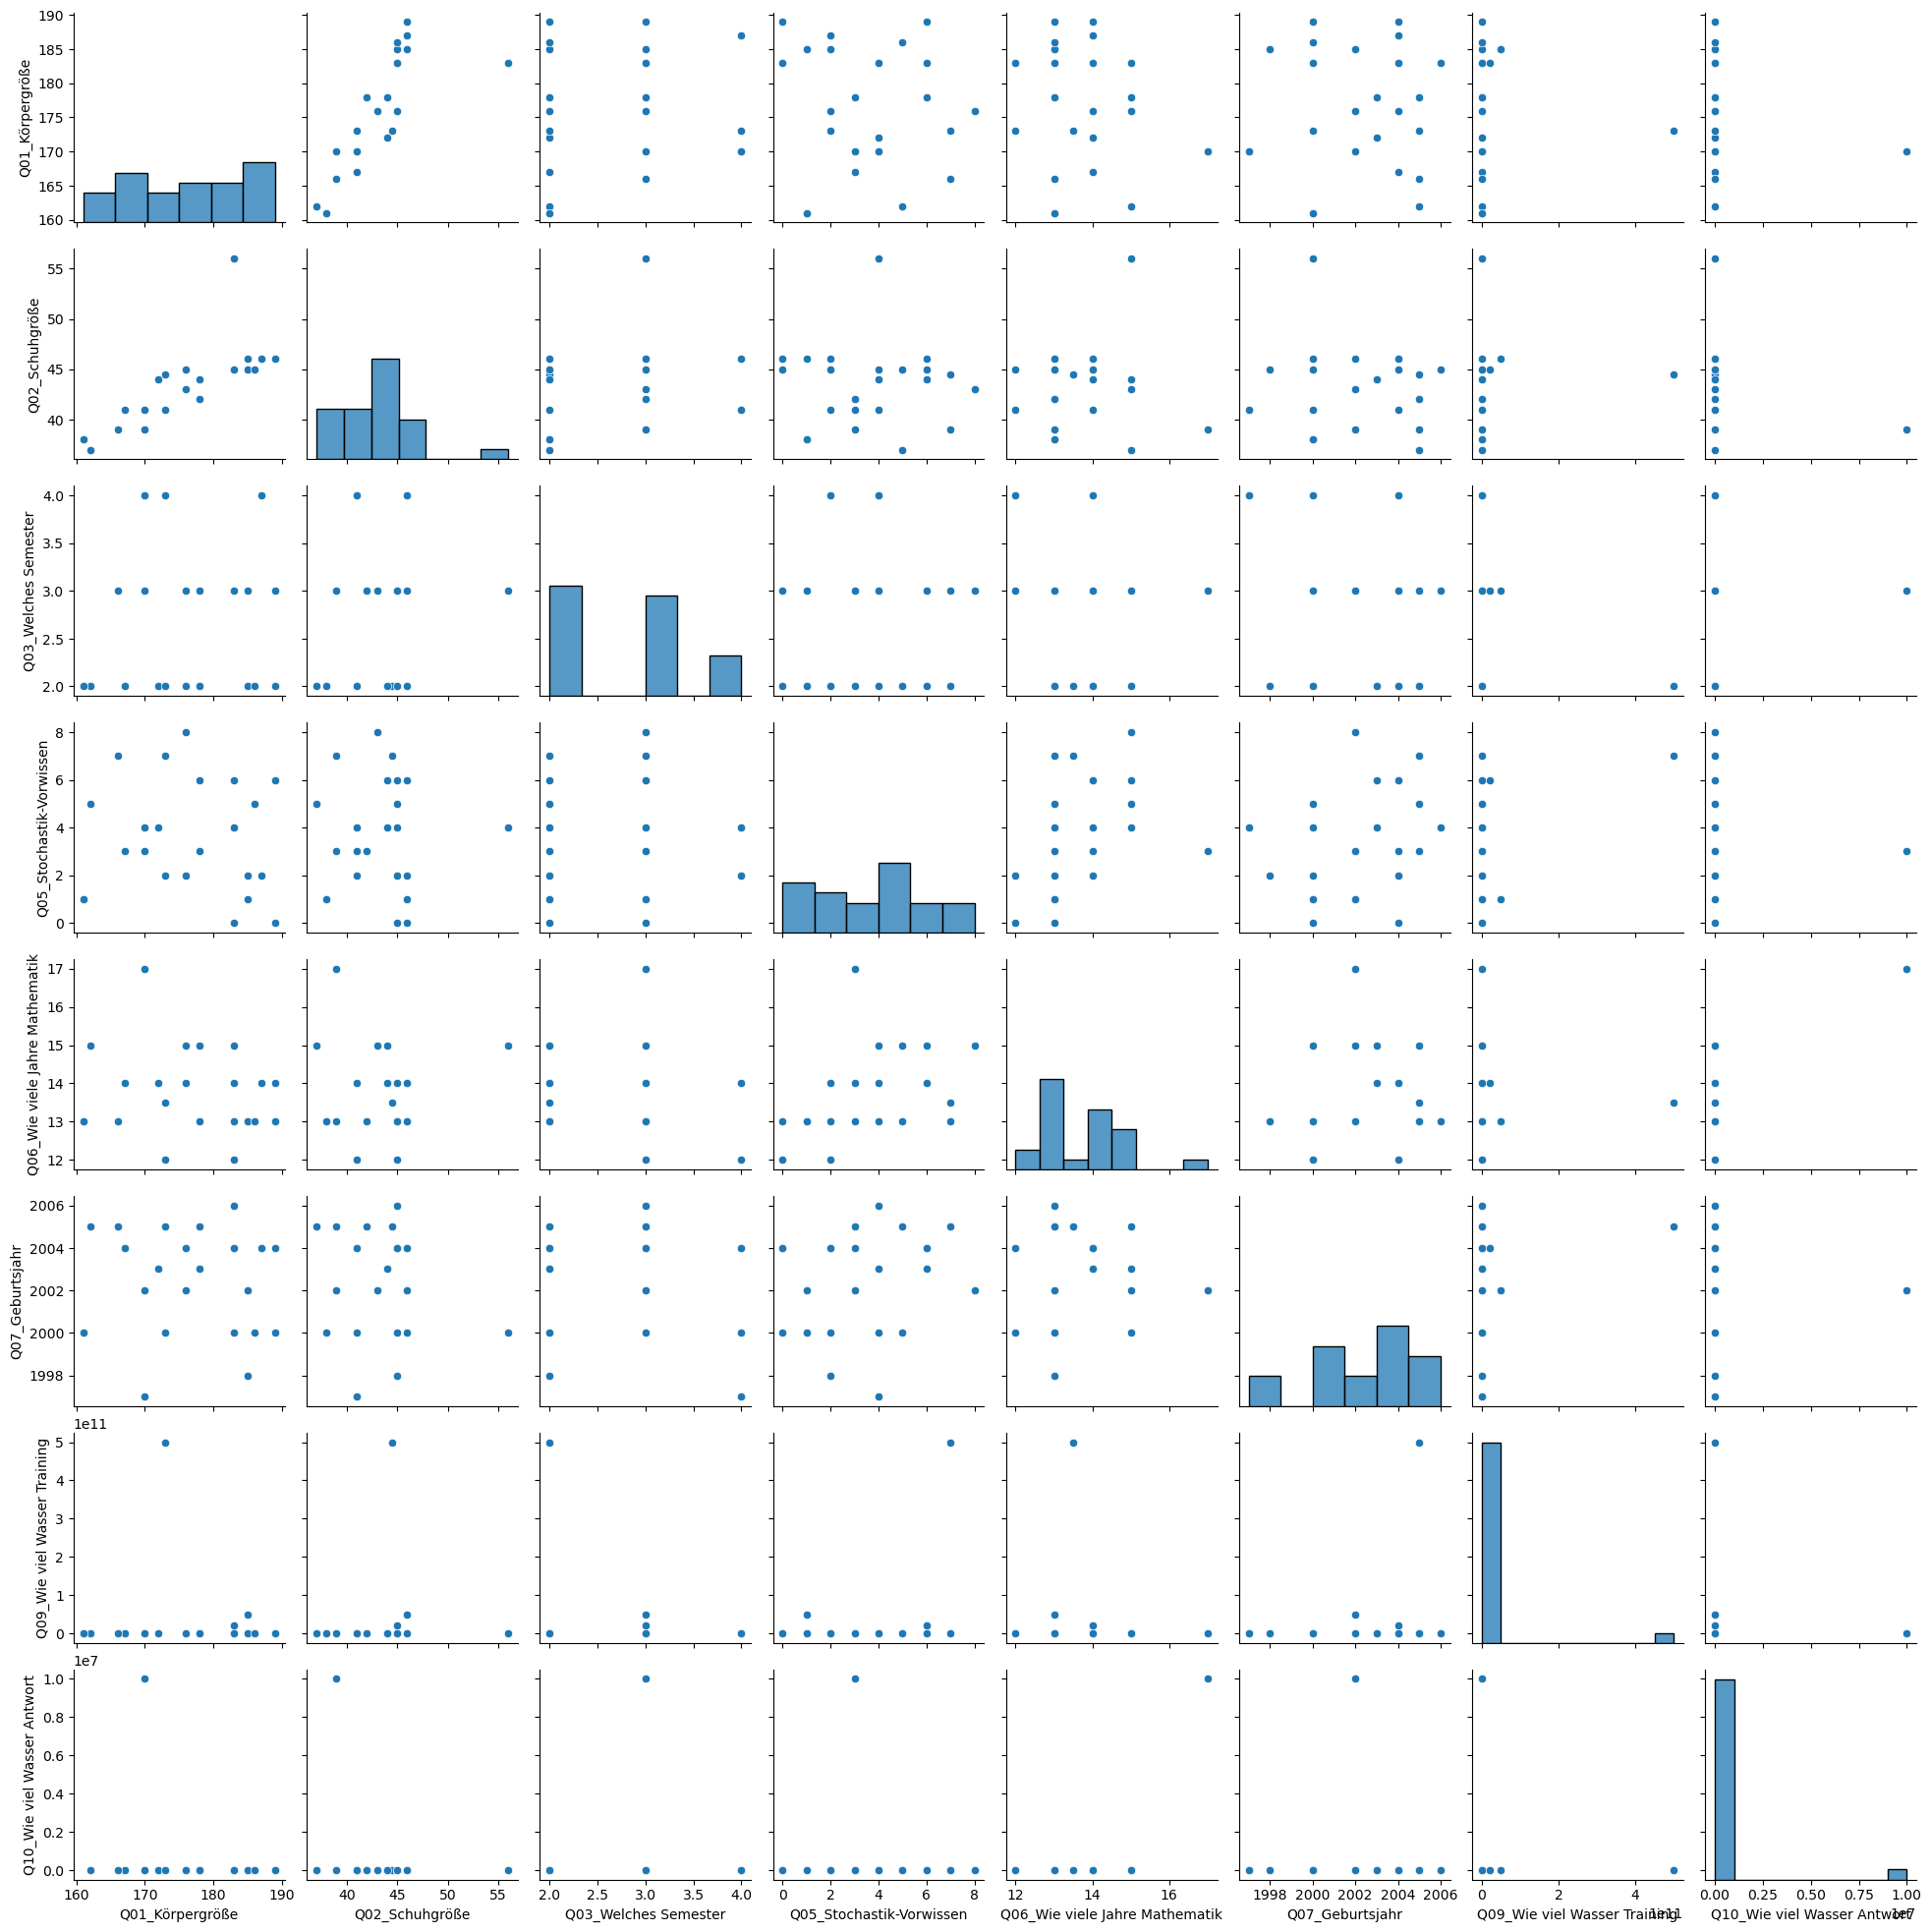

In [23]:
# und noch die Kombinationen aller möglichen Scatterplots (hier bedingt sinnvoll) 
sns.pairplot(numvals)